In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input

In [2]:
# Load Data
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1570s 9us/step
(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


In [3]:
# Normalize

X_train = X_train.astype('float32')/255.0
X_test = X_test.astype('float32')/255.0

In [4]:
# Remove extra dimension from labels
y_train = y_train.flatten() # Flatten() is a layer that converts 
                            # multi-dimensional data into a single 1D vector.
y_test = y_test.flatten()

print(X_train.shape)
print(y_train.shape)

(50000, 32, 32, 3)
(50000,)


In [12]:
tf.keras.utils.set_random_seed(42) # to give same result every time we run the code

model = Sequential([
    layers.Input(shape=(32, 32, 3)), # height, width, RGB

    layers.Conv2D(32, (3, 3), activation='relu'),# 32 filters & (3, 3) -> size of each filter
    layers.MaxPooling2D(), # it reduce the (height , width) in half ==> (32, 32) -> (16, 16)

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.Flatten(), # it transform data from 4 × 4 × 128 to  2048 values (like a traditional ANN.)

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [13]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# is simply used to see the structure of your neural network.
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [18]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

Epoch 1/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7177 - loss: 0.7981 - val_accuracy: 0.7627 - val_loss: 0.6601
Epoch 2/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7449 - loss: 0.7210 - val_accuracy: 0.7630 - val_loss: 0.6725
Epoch 3/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7677 - loss: 0.6596 - val_accuracy: 0.7564 - val_loss: 0.7060
Epoch 4/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7800 - loss: 0.6142 - val_accuracy: 0.7480 - val_loss: 0.7116
Epoch 5/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7951 - loss: 0.5769 - val_accuracy: 0.7439 - val_loss: 0.7390
Epoch 6/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8070 - loss: 0.5347 - val_accuracy: 0.7483 - val_loss: 0.7412
Epoch 7/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8212 - loss: 0.5002 - val_accuracy: 0.7522 - val_loss: 0.7316
Epoch 8/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8334 - loss: 0.4689 - val_accuracy: 0.

In [19]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7009 - loss: 1.0851
Test accuracy: 0.7009000182151794


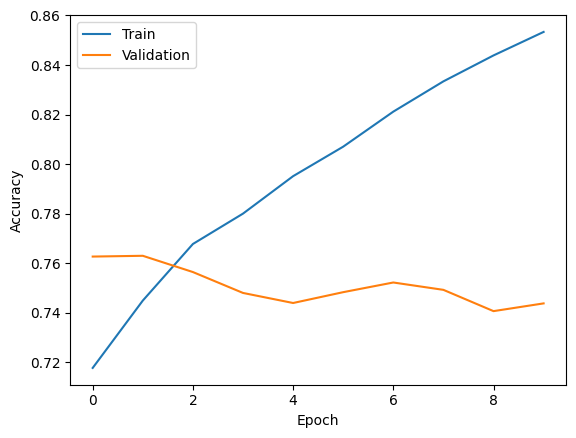

In [20]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

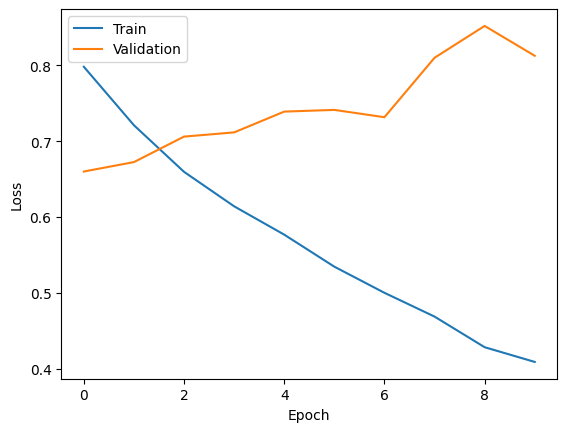

In [21]:
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()